In [10]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from typing import List, Union, Tuple, Literal

from model_ranking.utils import (
    load_h5,
)

In [2]:
def get_ckpt_eval_scores(path: Union[str, Path], checkpoint_ids: List[int], eval_key: str = "F1_eval") -> Tuple[List[float], List[float]]:
    mean_eval_scores: List[float] = []
    median_eval_scores: List[float] = []
    if isinstance(path, str):
        path = Path(path)
    for id in checkpoint_ids:
        checkpoint_name = f"epoch-{int(id)}"
        summary_path = path / checkpoint_name / "predictions" / "metric_summary.h5"
        eval_score_pp = load_h5(summary_path, eval_key)
        eval_mean = load_h5(summary_path, f"{eval_key}_mean") 
        eval_median = load_h5(summary_path, f"{eval_key}_median")
        mean_eval_scores.append(eval_mean[1])
        median_eval_scores.append(eval_median[1])
        assert np.all(np.equal(np.mean(eval_score_pp, axis=0), eval_mean)), f"Eval mean mismatch for {checkpoint_name} {eval_mean} vs {np.mean(eval_score_pp, axis=0)}"
    return mean_eval_scores, median_eval_scores

In [11]:
def plot_performance_per_epoch(
        scores: List[float],
        epochs: List[int],
        transfer: str,
        title:str,
        average: Literal["mean", "median"]="median",
        figsize: Tuple[int, int] = (10, 5),
):
        _ = plt.figure(figsize=figsize)
        _ = plt.plot(epochs, scores, marker='o', linestyle='-', color='b')
        _ =plt.title(f'{average} Evaluation Scores {transfer}: {title}')
        _ =plt.xlabel('Epoch number')
        _ =plt.ylabel(f'{average} Evaluation Score')
        _ = plt.xticks(epochs)
        plt.grid()
        plt.tight_layout()
        #plt.savefig("mean_eval_scores_over_checkpoints.png")
        plt.show()

# Direct Transfer Performance

In [23]:
path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/Hmito_to_EPFL_gap/consistency/P_3/Hm_model3/norm_Normalize/none/predictions/test_none.h5"
eval_score_direct = load_h5(path, "hard_f1")
eval_direct_mean = np.mean(eval_score_direct, axis=0)
eval_direct_median = np.median(eval_score_direct, axis=0)

# MeanTeacher Finetuning: DropOut Consistency Pseudolabeler

In [24]:
DO_mean_eval_scores, DO_median_eval_scores = get_ckpt_eval_scores(
    "/g/kreshuk/talks/model_ranking_results/Self-Finetuning/Mitochondria/Hmito_to_EPFL_gap/feature_perturbation/predictions/HtoE_DO_a02_model1",
    list(range(2, 22, 2)),
)
DO_mean_eval_scores.insert(0, eval_direct_mean[1])
DO_median_eval_scores.insert(0, eval_direct_median[1])

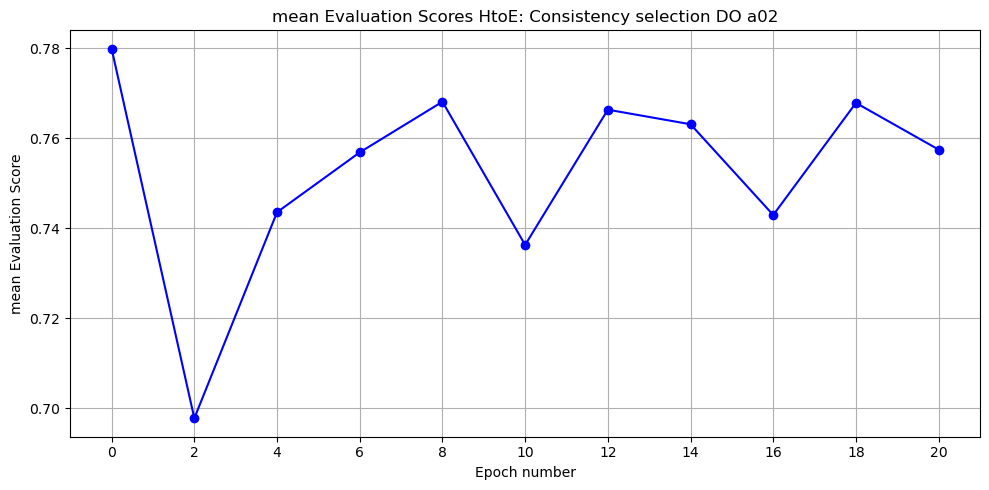

In [25]:
plot_performance_per_epoch(
    DO_mean_eval_scores,
    list(range(0, 22, 2)),
    "HtoE",
    "Consistency selection DO a02",
    average="mean",
)

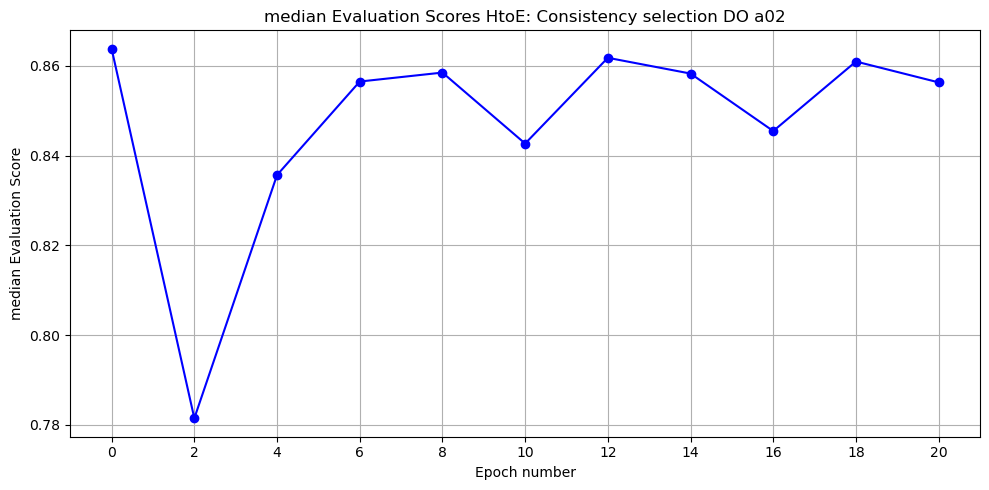

In [27]:
plot_performance_per_epoch(
    DO_median_eval_scores,
    list(range(0, 22, 2)),
    "HtoE",
    "Consistency selection DO a02",
    average="median",
)

# MeanTeacher Finetuning: Input Gaussian consistency Pseudolabeler

In [28]:
gauss_mean_eval_scores, gauss_median_eval_scores = get_ckpt_eval_scores(
    "/g/kreshuk/talks/model_ranking_results/Self-Finetuning/Mitochondria/Hmito_to_EPFL_gap/input_perturbation/predictions/HtoE_gauss_a0-005_model1",
    list(range(2, 22, 2)),
)
gauss_mean_eval_scores.insert(0, eval_direct_mean[1])
gauss_median_eval_scores.insert(0, eval_direct_median[1])

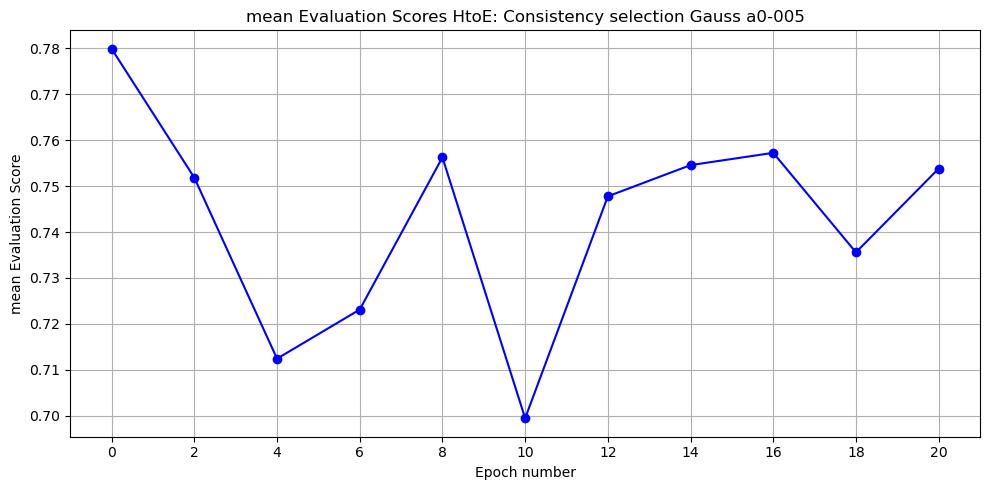

In [29]:
plot_performance_per_epoch(
    gauss_mean_eval_scores,
    list(range(0, 22, 2)),
    "HtoE",
    "Consistency selection Gauss a0-005",
    average="mean",
)

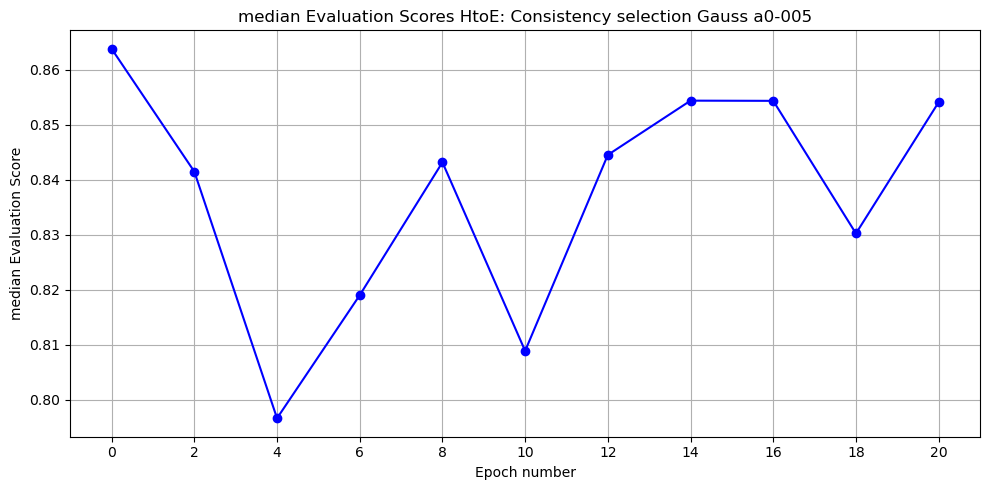

In [30]:
plot_performance_per_epoch(
    gauss_median_eval_scores,
    list(range(0, 22, 2)),
    "HtoE",
    "Consistency selection Gauss a0-005",
    average="median",
)

# Default Self-training

In [31]:
def_mean_eval_scores, def_median_eval_scores = get_ckpt_eval_scores(
    "/g/kreshuk/talks/model_ranking_results/Self-Finetuning/Mitochondria/Hmito_to_EPFL_gap/default_selftraining/predictions/HtoE_def_model1",
    list(range(2, 22, 2)),
)
def_mean_eval_scores.insert(0, eval_direct_mean[1])
def_median_eval_scores.insert(0, eval_direct_median[1])

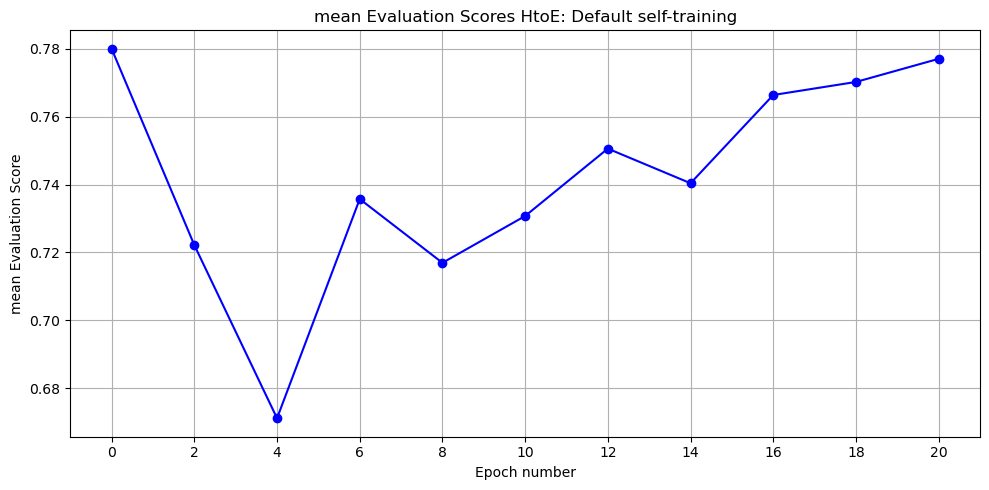

In [32]:
plot_performance_per_epoch(
    def_mean_eval_scores,
    list(range(0, 22, 2)),
    "HtoE",
    "Default self-training",
    average="mean",
)

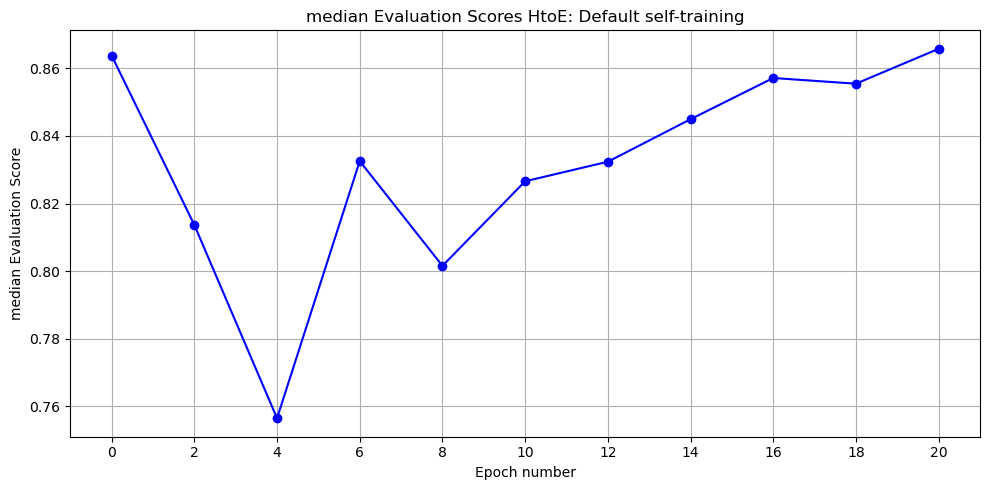

In [33]:
plot_performance_per_epoch(
    def_median_eval_scores,
    list(range(0, 22, 2)),
    "HtoE",
    "Default self-training",
    average="median",
)

# Confidence Threshold

In [34]:
cfd_mean_eval_scores, cfd_median_eval_scores = get_ckpt_eval_scores(
    "/g/kreshuk/talks/model_ranking_results/Self-Finetuning/Mitochondria/Hmito_to_EPFL_gap/confidence_threshold/predictions/HtoE_cfd_model1",
    list(range(2, 22, 2)),
)
cfd_mean_eval_scores.insert(0, eval_direct_mean[1])
cfd_median_eval_scores.insert(0, eval_direct_median[1])

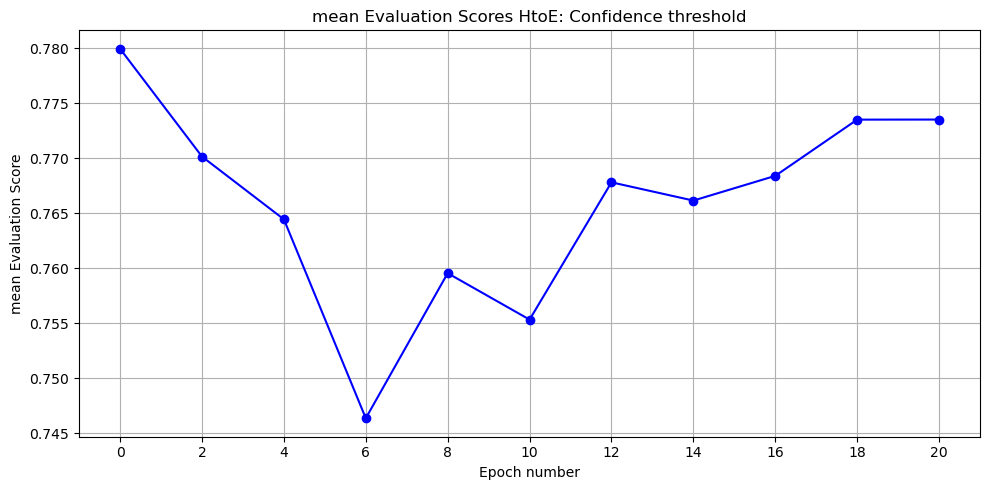

In [35]:
plot_performance_per_epoch(
    cfd_mean_eval_scores,
    list(range(0, 22, 2)),
    "HtoE",
    "Confidence threshold",
    average="mean",
)

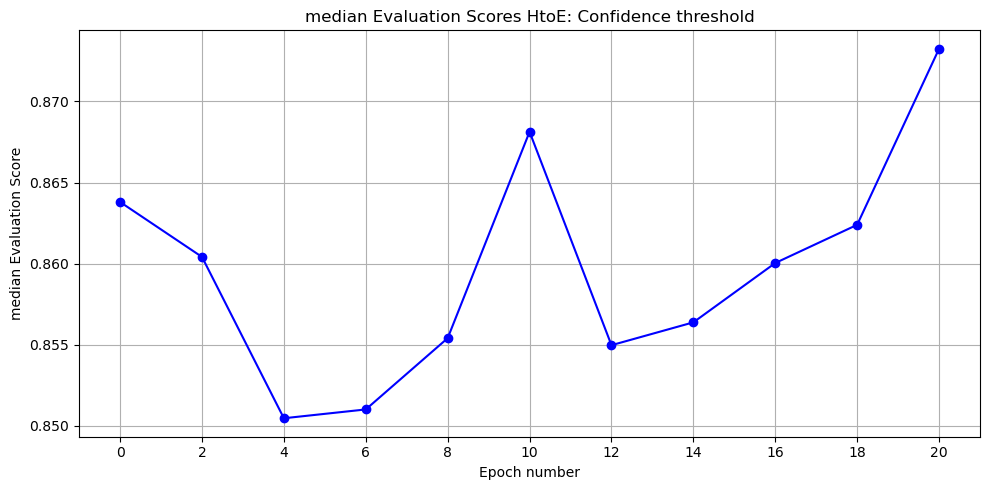

In [36]:
plot_performance_per_epoch(
    cfd_median_eval_scores,
    list(range(0, 22, 2)),
    "HtoE",
    "Confidence threshold",
    average="median",
)

# Combined

In [38]:
DO_mean_eval_scores2, DO_median_eval_scores2 = get_ckpt_eval_scores(
    "/g/kreshuk/talks/model_ranking_results/Self-Finetuning/Mitochondria/Hmito_to_EPFL_gap/feature_perturbation/predictions/HtoE_DO_a02_model2",
    list(range(2, 22, 2)),
)
DO_mean_eval_scores2.insert(0, eval_direct_mean[1])
DO_median_eval_scores2.insert(0, eval_direct_median[1])

In [41]:
DO_mean_eval_scores3, DO_median_eval_scores3 = get_ckpt_eval_scores(
    "/g/kreshuk/talks/model_ranking_results/Self-Finetuning/Mitochondria/Hmito_to_EPFL_gap/feature_perturbation/predictions/HtoE_DO_a02_model3",
    list(range(2, 22, 2)),
)
DO_mean_eval_scores3.insert(0, eval_direct_mean[1])
DO_median_eval_scores3.insert(0, eval_direct_median[1])

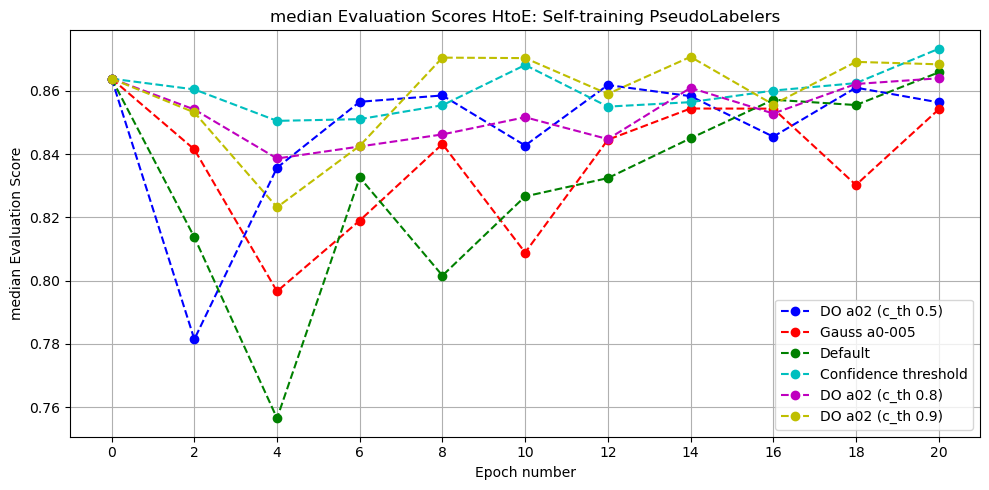

In [42]:
epochs = list(range(0, 22, 2))
average = "median"
transfer = "HtoE"
title = "Self-training PseudoLabelers"
_ = plt.figure(figsize=(10,5))
_ = plt.plot(epochs, DO_median_eval_scores, marker='o', linestyle='--', color='b', label='DO a02 (c_th 0.5)')
_ = plt.plot(epochs, gauss_median_eval_scores, marker='o', linestyle='--', color='r', label='Gauss a0-005')
_ = plt.plot(epochs, def_median_eval_scores, marker='o', linestyle='--', color='g', label='Default')
_ = plt.plot(epochs, cfd_median_eval_scores, marker='o', linestyle='--', color='c', label='Confidence threshold')
_ = plt.plot(epochs, DO_median_eval_scores2, marker='o', linestyle='--', color='m', label='DO a02 (c_th 0.8)')
_ = plt.plot(epochs, DO_median_eval_scores3, marker='o', linestyle='--', color='y', label='DO a02 (c_th 0.9)')
_ =plt.title(f'{average} Evaluation Scores {transfer}: {title}')
_ =plt.xlabel('Epoch number')
_ =plt.ylabel(f'{average} Evaluation Score')
_ = plt.xticks(epochs)
_ = plt.legend()
plt.grid()
plt.tight_layout()
#plt.savefig("mean_eval_scores_over_checkpoints.png")
plt.show()